In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import json
import numpy as np
import pandas as pd

DATASET_ROOT = "/content/drive/MyDrive/BATTERY_SOC_PROJECT/Dataset_Li-ion"
FROZEN_DIR = "/content/drive/MyDrive/frozen_dataset"
FEATURE_DIR = "/content/drive/MyDrive/feature_engineering_v1"
BASELINE_DIR = "/content/drive/MyDrive/day 15/baseline_v1"
ENSEMBLE_DIR = "/content/drive/MyDrive/day16/ensemble_v1"

TRAIN_PATH = f"/content/drive/MyDrive/frozen_dataset/dataset_v1_train.csv"
TEST_PATH = f"/content/drive/MyDrive/frozen_dataset/dataset_v1_test.csv"
FULL_PATH = f"/content/drive/MyDrive/frozen_dataset/dataset_v1_full.csv"
ENGINEERED_PATH = f"/content/drive/MyDrive/feature_engineering_v1/engineered_dataset.csv"
BASELINE_METRICS_PATH = f"/content/drive/MyDrive/day 15/baseline_v1/baseline_metrics.csv"
ENSEMBLE_METRICS_PATH = f"/content/drive/MyDrive/day16/ensemble_v1/train_test_metrics.csv"

for p in [TRAIN_PATH, TEST_PATH, FULL_PATH]:
    assert os.path.exists(p), f"Couldn't find {p} — check the Day 12 copy step."

TARGET_COLUMN = "soc_percent"
RAW_FEATURES = ["voltage_v", "current_a", "cell_temp_c", "power_w", "ambient_temp_c"]
RATED_CAPACITY_AH = 3.0

df_train_raw = pd.read_csv(TRAIN_PATH)
df_test_raw = pd.read_csv(TEST_PATH)
df_full = pd.read_csv(FULL_PATH)
print(f"Frozen split loaded — train: {df_train_raw.shape}, test: {df_test_raw.shape}")
print(f"Full dataset (has status/prog_time) loaded: {df_full.shape}")

HAVE_ENGINEERED = os.path.exists(ENGINEERED_PATH)
if HAVE_ENGINEERED:
    df_eng_full = pd.read_csv(ENGINEERED_PATH)
    print(f"Engineered dataset found: {df_eng_full.shape}")
else:
    print("⚠️  Engineered dataset not found — ANN will fall back to raw features.")

HAVE_BASELINE = os.path.exists(BASELINE_METRICS_PATH)
HAVE_ENSEMBLE = os.path.exists(ENSEMBLE_METRICS_PATH)
prior_metrics = []
if HAVE_BASELINE:
    baseline_df = pd.read_csv(BASELINE_METRICS_PATH, index_col=0)
    prior_metrics.append(baseline_df[["MAE", "RMSE", "R2"]])
    print("\nDay 15 baseline metrics loaded.")
if HAVE_ENSEMBLE:
    ensemble_df = pd.read_csv(ENSEMBLE_METRICS_PATH, index_col=0)
    ensemble_test = ensemble_df[ensemble_df.index.str.endswith("(test)")].copy()
    ensemble_test.index = ensemble_test.index.str.replace(" (test)", "", regex=False)
    prior_metrics.append(ensemble_test[["MAE", "RMSE", "R2"]])
    print("Day 16 ensemble metrics loaded.")
prior_results_df = pd.concat(prior_metrics) if prior_metrics else pd.DataFrame(columns=["MAE", "RMSE", "R2"])

Frozen split loaded — train: (76792, 7), test: (27768, 7)
Full dataset (has status/prog_time) loaded: (104560, 19)
Engineered dataset found: (104525, 5)

Day 15 baseline metrics loaded.
Day 16 ensemble metrics loaded.


In [3]:
ENGINEERED_FEATURES = None
if HAVE_ENGINEERED:
    key_cols = ["file_id", "timestamp"]
    eng_cols = [c for c in df_eng_full.columns if c not in key_cols + [TARGET_COLUMN]]
    train_ids = df_train_raw["file_id"].unique()
    test_ids = df_test_raw["file_id"].unique()
    df_eng_train = df_eng_full[df_eng_full["file_id"].isin(train_ids)].copy()
    df_eng_test = df_eng_full[df_eng_full["file_id"].isin(test_ids)].copy()
    ENGINEERED_FEATURES = eng_cols
    print(f"Engineered features ({len(ENGINEERED_FEATURES)}): {ENGINEERED_FEATURES}")

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def score(y_true, y_pred, label):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"[{label}] MAE={mae:.3f}  RMSE={rmse:.3f}  R2={r2:.4f}")
    return {"label": label, "MAE": mae, "RMSE": rmse, "R2": r2}

Engineered features (2): ['voltage_roll_std5', 'current_roll_std5']


In [4]:
print("===== ANN JUSTIFICATION CHECK =====")
n_train_rows = len(df_eng_train) if HAVE_ENGINEERED else len(df_train_raw)
print(f"""
Target: SOC (%)
  - Row count available for training: {n_train_rows:,}
  - Relationship shape: voltage/current/temperature -> SOC is smooth and
    continuous but has known NON-LINEAR regions (e.g. steep voltage knee
    near full discharge) that a plain linear model under-fits.
  - Day 16's tree ensembles already model non-linearity well, so an ANN
    is not being added to "beat" them by architecture alone — it's added
    because a differentiable, smooth function approximator is a genuinely
    different inductive bias worth comparing against tree splits, and the
    row count above is large enough to train one without memorizing.
  DECISION: ANN justified for SOC. Proceeding to Cell 4.
""")

===== ANN JUSTIFICATION CHECK =====

Target: SOC (%)
  - Row count available for training: 76,764
  - Relationship shape: voltage/current/temperature -> SOC is smooth and
    continuous but has known NON-LINEAR regions (e.g. steep voltage knee
    near full discharge) that a plain linear model under-fits.
  - Day 16's tree ensembles already model non-linearity well, so an ANN
    is not being added to "beat" them by architecture alone — it's added
    because a differentiable, smooth function approximator is a genuinely
    different inductive bias worth comparing against tree splits, and the
    row count above is large enough to train one without memorizing.
  DECISION: ANN justified for SOC. Proceeding to Cell 4.



In [5]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler

ann_features = ENGINEERED_FEATURES if HAVE_ENGINEERED else RAW_FEATURES
ann_train_df = df_eng_train if HAVE_ENGINEERED else df_train_raw
ann_test_df = df_eng_test if HAVE_ENGINEERED else df_test_raw


gss_val = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=42)
tr_idx, val_idx = next(gss_val.split(ann_train_df, groups=ann_train_df["file_id"]))
df_fit = ann_train_df.iloc[tr_idx]
df_val = ann_train_df.iloc[val_idx]

X_fit_raw = df_fit[ann_features].values
X_val_raw = df_val[ann_features].values
X_test_raw_ann = ann_test_df[ann_features].values
y_fit = df_fit[TARGET_COLUMN].values
y_val = df_val[TARGET_COLUMN].values
y_test_ann = ann_test_df[TARGET_COLUMN].values


scaler = StandardScaler().fit(X_fit_raw)
X_fit = scaler.transform(X_fit_raw)
X_val = scaler.transform(X_val_raw)
X_test_ann = scaler.transform(X_test_raw_ann)

print(f"ANN data — fit: {X_fit.shape}, val: {X_val.shape}, test: {X_test_ann.shape}")


ANN data — fit: (62097, 2), val: (14667, 2), test: (27761, 2)


In [9]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

tf.random.set_seed(42)

def build_soc_mlp(n_features):
    model = keras.Sequential([
        layers.Input(shape=(n_features,)),
        layers.Dense(64, activation="relu"),
        layers.Dropout(0.15),
        layers.Dense(32, activation="relu"),
        layers.Dropout(0.10),
        layers.Dense(1, activation="linear"),
    ], name="soc_mlp")
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3),
                  loss="mse", metrics=["mae"])
    return model

soc_mlp = build_soc_mlp(len(ann_features))
soc_mlp.summary()

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=10, restore_best_weights=True
)

history = soc_mlp.fit(
    X_fit, y_fit,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=256,
    callbacks=[early_stop],
    verbose=2,
)

Model: "soc_mlp"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 64)             │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,305 (9.00 KB)

 Trainable params: 2,305 (9.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
243/243 - 11s - 44ms/step - loss: 2371.2529 - mae: 40.9445 - val_loss: 1058.2092 - val_mae: 29.5474
Epoch 2/10
243/243 - 1s - 3ms/step - loss: 819.2618 - mae: 24.0187 - val_loss: 1174.4871 - val_mae: 31.4051
Epoch 3/10
243/243 - 1s - 3ms/step - loss: 725.2828 - mae: 22.9853 - val_loss: 1254.4441 - val_mae: 32.2918
Epoch 4/10
243/243 - 1s - 3ms/step - loss: 717.7168 - mae: 22.9016 - val_loss: 1291.0896 - val_mae: 32.6780
Epoch 5/10
243/243 - 1s - 3ms/step - loss: 713.6735 - mae: 22.8598 - val_loss: 1291.5607 - val_mae: 32.6811
Epoch 6/10
243/243 - 1s - 3ms/step - loss: 712.9913 - mae: 22.8582 - val_loss: 1301.4451 - val_mae: 32.7788
Epoch 7/10
243/243 - 1s - 3ms/step - loss: 712.3416 - mae: 22.8481 - val_loss: 1285.4062 - val_mae: 32.6018
Epoch 8/10
243/243 - 1s - 3ms/step - loss: 712.6493 - mae: 22.8629 - val_loss: 1278.8374 - val_mae: 32.5262
Epoch 9/10
243/243 - 1s - 3ms/step - loss: 712.7952 - mae: 22.8529 - val_loss: 1291.0724 - val_mae: 32.6666
Epoch 10/10
243/243 - 2s 

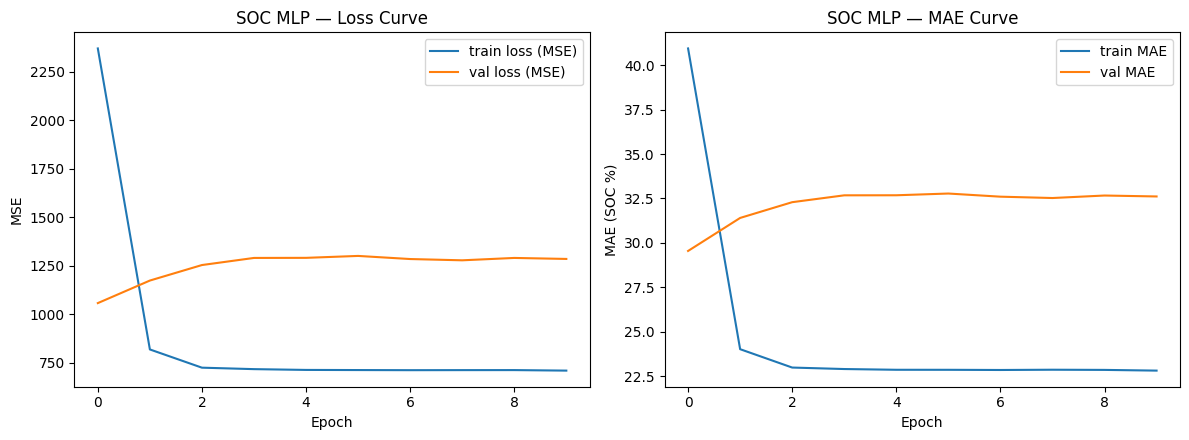


Training stopped at epoch 10 (EarlyStopping patience=10, restored best weights).
Final train/val loss gap: +575.8185 (notable — watch for overfitting)


In [10]:
import matplotlib.pyplot as plt

os.makedirs("ann_v1", exist_ok=True)

hist_df = pd.DataFrame(history.history)
hist_df.to_csv("ann_v1/training_history.csv", index_label="epoch")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(hist_df["loss"], label="train loss (MSE)")
axes[0].plot(hist_df["val_loss"], label="val loss (MSE)")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("MSE"); axes[0].legend()
axes[0].set_title("SOC MLP — Loss Curve")

axes[1].plot(hist_df["mae"], label="train MAE")
axes[1].plot(hist_df["val_mae"], label="val MAE")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("MAE (SOC %)"); axes[1].legend()
axes[1].set_title("SOC MLP — MAE Curve")
plt.tight_layout()
plt.savefig("ann_v1/soc_mlp_training_curves.png", dpi=150)
plt.show()

stopped_epoch = early_stop.stopped_epoch if early_stop.stopped_epoch > 0 else len(hist_df)
final_gap = hist_df["val_loss"].iloc[-1] - hist_df["loss"].iloc[-1]
print(f"\nTraining stopped at epoch {stopped_epoch} "
      f"(EarlyStopping patience=10, restored best weights).")
print(f"Final train/val loss gap: {final_gap:+.4f} "
      f"({'small — no strong overfit signal' if abs(final_gap) < 0.5 * hist_df['loss'].iloc[-1] else 'notable — watch for overfitting'})")



===== SOC MLP — TEST SET =====
[MLP — SOC] MAE=25.932  RMSE=31.611  R2=-0.3839


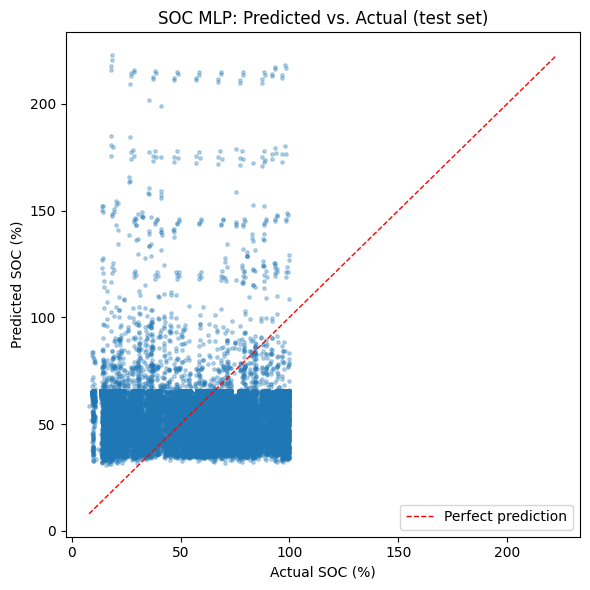

In [11]:
y_pred_soc_mlp = soc_mlp.predict(X_test_ann, verbose=0).flatten()
print("\n===== SOC MLP — TEST SET =====")
soc_mlp_result = score(y_test_ann, y_pred_soc_mlp, "MLP — SOC")

plt.figure(figsize=(6, 6))
plt.scatter(y_test_ann, y_pred_soc_mlp, s=6, alpha=0.3)
lims = [min(y_test_ann.min(), y_pred_soc_mlp.min()), max(y_test_ann.max(), y_pred_soc_mlp.max())]
plt.plot(lims, lims, "r--", linewidth=1, label="Perfect prediction")
plt.xlabel("Actual SOC (%)"); plt.ylabel("Predicted SOC (%)")
plt.title("SOC MLP: Predicted vs. Actual (test set)")
plt.legend(); plt.tight_layout()
plt.savefig("ann_v1/soc_mlp_pred_vs_actual.png", dpi=150)
plt.show()

In [12]:
print("\n===== ENGINEERING: REMAINING CHARGING TIME =====")
print("Definition: for every row inside a contiguous 'CHA' (charging) "
      "segment within a file, remaining_charge_time_s = the time (in "
      "seconds) between this row and the LAST row of that same charging "
      "segment. Rows outside a charging segment don't have this target.")

df_full["prog_time_td"] = pd.to_timedelta(df_full["prog_time"], errors="coerce")
df_full = df_full.sort_values(["file_id", "prog_time_td"]).reset_index(drop=True)


df_full["status_change"] = (
    (df_full["status"] != df_full["status"].shift(1)) |
    (df_full["file_id"] != df_full["file_id"].shift(1))
)
df_full["segment_id"] = df_full["status_change"].cumsum()

df_charge = df_full[df_full["status"] == "CHA"].copy()
if len(df_charge) == 0:
    print("⚠️  No rows with status == 'CHA' found — check the status values "
          "in your dataset_v1_full.csv (they may use a different code).")
else:
    seg_end_time = df_charge.groupby("segment_id")["prog_time_td"].transform("max")
    df_charge["remaining_charge_time_s"] = (seg_end_time - df_charge["prog_time_td"]).dt.total_seconds()
    n_segments = df_charge["segment_id"].nunique()
    print(f"Found {len(df_charge)} charging rows across {n_segments} charging segments "
          f"(across {df_charge['file_id'].nunique()} files).")
    print(df_charge["remaining_charge_time_s"].describe())

CHARGE_TARGET = "remaining_charge_time_s"
CHARGE_FEATURES = ["voltage_v", "current_a", "cell_temp_c", "ambient_temp_c"]

print(f"""
===== ANN JUSTIFICATION CHECK (remaining charging time) =====
  - Charging segments found: {n_segments if len(df_charge) else 0}
  - Rows available: {len(df_charge)}
  - This is a MUCH smaller, more repetitive dataset than SOC's (one
    charge profile per file, following the same CC-CV procedure each
    time) — an MLP here would either memorize the handful of segments
    or need heavy regularization that erases any advantage over a
    simpler model.
  DECISION: ANN NOT justified for remaining charging time. Using Random
  Forest instead (Cell 7) — consistent with "train an ANN only where
  the dataset justifies it," not as a default for every target.
""")


===== ENGINEERING: REMAINING CHARGING TIME =====
Definition: for every row inside a contiguous 'CHA' (charging) segment within a file, remaining_charge_time_s = the time (in seconds) between this row and the LAST row of that same charging segment. Rows outside a charging segment don't have this target.
Found 1335 charging rows across 67 charging segments (across 17 files).
count     1299.000000
mean      3661.441977
std      12202.441418
min          0.000000
25%          5.999500
50%        160.996000
75%        485.499000
max      72000.000000
Name: remaining_charge_time_s, dtype: float64

===== ANN JUSTIFICATION CHECK (remaining charging time) =====
  - Charging segments found: 67
  - Rows available: 1335
  - This is a MUCH smaller, more repetitive dataset than SOC's (one
    charge profile per file, following the same CC-CV procedure each
    time) — an MLP here would either memorize the handful of segments
    or need heavy regularization that erases any advantage over a
    simp


===== RANDOM FOREST — remaining charging time =====
[RandomForest — charging time] MAE=9001.754  RMSE=18410.153  R2=-0.1602


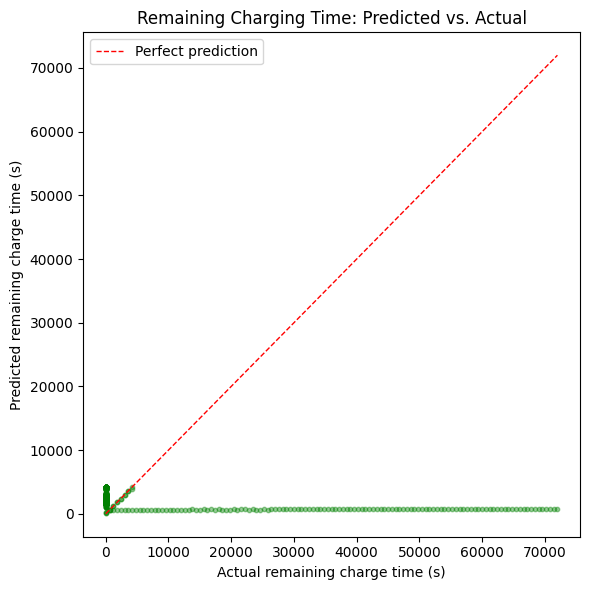

In [17]:
from sklearn.ensemble import RandomForestRegressor

if len(df_charge) > 20 and df_charge["file_id"].nunique() > 1:

    df_charge = df_charge.dropna(subset=[CHARGE_TARGET])

    gss_charge = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
    c_train_idx, c_test_idx = next(gss_charge.split(df_charge, groups=df_charge["file_id"]))
    charge_train = df_charge.iloc[c_train_idx]
    charge_test = df_charge.iloc[c_test_idx]

    X_charge_train = charge_train[CHARGE_FEATURES]
    y_charge_train = charge_train[CHARGE_TARGET]
    X_charge_test = charge_test[CHARGE_FEATURES]
    y_charge_test = charge_test[CHARGE_TARGET]

    rf_charge = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1)
    rf_charge.fit(X_charge_train, y_charge_train)
    y_pred_charge = rf_charge.predict(X_charge_test)

    print("\n===== RANDOM FOREST — remaining charging time =====")
    charge_result = score(y_charge_test, y_pred_charge, "RandomForest — charging time")

    plt.figure(figsize=(6, 6))
    plt.scatter(y_charge_test, y_pred_charge, s=10, alpha=0.4, color="green")
    lims = [0, max(y_charge_test.max(), y_pred_charge.max())]
    plt.plot(lims, lims, "r--", linewidth=1, label="Perfect prediction")
    plt.xlabel("Actual remaining charge time (s)")
    plt.ylabel("Predicted remaining charge time (s)")
    plt.title("Remaining Charging Time: Predicted vs. Actual")
    plt.legend(); plt.tight_layout()
    plt.savefig("ann_v1/charging_time_pred_vs_actual.png", dpi=150)
    plt.show()
else:
    charge_result = None
    print("⚠️  Too few charging segments/files to fit a grouped model reliably "
          "— revisit CHARGE detection logic or gather more temperature folders.")

In [18]:
soc_mlp_params = soc_mlp.count_params()
print("\n===== COMPLEXITY COMPARISON =====")
print(f"SOC MLP: {soc_mlp_params:,} trainable parameters "
      f"({len(soc_mlp.layers)} layers: 64 -> dropout -> 32 -> dropout -> 1)")
print("Day 15 Linear Regression: 1 coefficient per feature + intercept "
      f"({len(ann_features)+1} parameters) — orders of magnitude simpler.")
print("Day 16 Random Forest / Gradient Boosting: no single 'parameter count' "
      "analog, but n_estimators x max_depth controls effective complexity "
      "(e.g. 300 trees x depth 14 for RF) — complexity is comparable in "
      "spirit to the MLP's parameter count, just structured differently.")
print("RandomForest (charging time): 200 trees x depth 10 — much smaller "
      "than the SOC ensemble, sized down for the smaller charging dataset.")


===== COMPLEXITY COMPARISON =====
SOC MLP: 2,305 trainable parameters (5 layers: 64 -> dropout -> 32 -> dropout -> 1)
Day 15 Linear Regression: 1 coefficient per feature + intercept (3 parameters) — orders of magnitude simpler.
Day 16 Random Forest / Gradient Boosting: no single 'parameter count' analog, but n_estimators x max_depth controls effective complexity (e.g. 300 trees x depth 14 for RF) — complexity is comparable in spirit to the MLP's parameter count, just structured differently.
RandomForest (charging time): 200 trees x depth 10 — much smaller than the SOC ensemble, sized down for the smaller charging dataset.


In [19]:
import datetime

soc_mlp.save("ann_v1/soc_mlp.keras")
import joblib
joblib.dump(scaler, "ann_v1/soc_mlp_scaler.joblib")
if charge_result is not None:
    joblib.dump(rf_charge, "ann_v1/charging_time_rf.joblib")

all_results_df = pd.DataFrame([soc_mlp_result] + ([charge_result] if charge_result else [])).set_index("label")
if not prior_results_df.empty:
    full_comparison = pd.concat([prior_results_df, all_results_df])
else:
    full_comparison = all_results_df
full_comparison.to_csv("ann_v1/day17_metrics.csv")
print("\n===== FULL COMPARISON SO FAR (Day 15/16 + Day 17) =====")
print(full_comparison.sort_values("MAE").to_string())

with open("ann_v1/summary.txt", "w") as f:
    f.write("Day 17 — Additional / Neural Model\n")
    f.write(f"Generated: {datetime.datetime.now()}\n\n")
    f.write("SOC target: small MLP justified — large row count, smooth but "
            "non-linear V/I/T -> SOC relationship, different inductive bias "
            "from Day 16's trees.\n")
    f.write(f"  Architecture: 64 -> Dropout(0.15) -> 32 -> Dropout(0.10) -> 1, "
            f"{soc_mlp_params:,} trainable params.\n")
    f.write(f"  Training stopped at epoch {stopped_epoch} (EarlyStopping, patience=10).\n")
    f.write(f"  Test MAE={soc_mlp_result['MAE']:.3f} SOC%, "
            f"RMSE={soc_mlp_result['RMSE']:.3f}, R2={soc_mlp_result['R2']:.4f}\n\n")
    f.write("Remaining charging time target: NEW, engineered in this notebook "
            "from status=='CHA' segments (see Cell 6 for exact definition).\n")
    f.write(f"  Charging rows: {len(df_charge)}, segments: {n_segments if len(df_charge) else 0}.\n")
    f.write("  ANN explicitly NOT used here — too few/repetitive segments to "
            "train a network without memorizing. Random Forest used instead.\n")
    if charge_result:
        f.write(f"  Test MAE={charge_result['MAE']:.3f}s, RMSE={charge_result['RMSE']:.3f}s, "
                f"R2={charge_result['R2']:.4f}\n")
    f.write("\nFull comparison (all models, all days):\n")
    f.write(full_comparison.sort_values("MAE").to_string())

print("\n✅ Artifacts saved in 'ann_v1/':")
for f in sorted(os.listdir("ann_v1")):
    print(" -", f)



===== FULL COMPARISON SO FAR (Day 15/16 + Day 17) =====
                                      MAE          RMSE        R2
label                                                            
RandomForest — raw               3.284465     10.474381  0.848121
XGBoost — raw                    3.300615     10.082012  0.859287
Linear — raw                     3.472758      4.585786  0.970888
XGBoost — engineered            22.598706     27.527405 -0.049465
RandomForest — engineered       22.942698     28.916572 -0.158060
Mean baseline                   23.041381     27.508849 -0.047575
Linear — engineered             23.193436     27.771279 -0.068143
MLP — SOC                       25.932455     31.611177 -0.383945
RandomForest — charging time  9001.753713  18410.153468 -0.160202

✅ Artifacts saved in 'ann_v1/':
 - charging_time_pred_vs_actual.png
 - charging_time_rf.joblib
 - day17_metrics.csv
 - soc_mlp.keras
 - soc_mlp_pred_vs_actual.png
 - soc_mlp_scaler.joblib
 - soc_mlp_training_curves.p

In [20]:
import shutil
shutil.copytree("ann_v1", "/content/drive/MyDrive/Dataset_Li-ion/ann_v1", dirs_exist_ok=True)

'/content/drive/MyDrive/Dataset_Li-ion/ann_v1'